In [38]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import rfft, rfftfreq
from scipy.signal import detrend, find_peaks
from scipy.interpolate import interp1d
import os

In [39]:
# 1. Constants and setup
# Gravitational constant in AU^3 / (yr^2 * M_sun)
# Chosen so that a=1 AU, M=1 M_sun gives P=1 yr
G = 4 * np.pi**2

S0 = 1361.0          # Solar constant (W/m^2)
M_SUN = 1.0
M_EARTH = 3.003e-6   # in solar masses
M_JUPITER = 9.545e-4 # in solar masses

EARTH_R0 = 1.0       # AU
EARTH_V0 = 2 * np.pi # AU/yr (circular)
EARTH_V0_ECCENTRIC = 2 * np.pi * 1.01

JUPITER_R0 = 5.2     # AU
JUPITER_V0 = 2 * np.pi / np.sqrt(JUPITER_R0)

SOFTENING = 0.01     # AU (1% of Earth–Sun distance)

phi_65N = np.radians(65.0)

In [40]:
# 2. N-body dynamics
def acceleration(positions, masses, softening=SOFTENING):
    """
    Compute gravitational accelerations on each body (2D).
    positions: (N, 2)
    masses: (N,)
    """
    diff = positions[np.newaxis, :, :] - positions[:, np.newaxis, :]
    dist_sq = np.sum(diff**2, axis=-1) + softening**2
    inv_dist_cube = dist_sq**(-1.5)
    np.fill_diagonal(inv_dist_cube, 0.0)

    acc = G * np.sum(masses[np.newaxis, :, np.newaxis] *
                     diff * inv_dist_cube[:, :, np.newaxis], axis=1)
    return acc


def rk4_step(positions, velocities, masses, dt):
    a1 = acceleration(positions, masses, G)
    a2 = acceleration(positions + 0.5 * dt * velocities, masses, G)
    a3 = acceleration(positions + 0.5 * dt * (velocities + 0.5 * dt * a1), masses, G)
    a4 = acceleration(positions + dt * (velocities + 0.5 * dt * a2), masses, G)

    new_positions = positions + (dt / 6.0) * (
        velocities
        + 2 * (velocities + 0.5 * dt * a1)
        + 2 * (velocities + 0.5 * dt * a2)
        + (velocities + dt * a3)
    )
    new_velocities = velocities + (dt / 6.0) * (a1 + 2 * a2 + 2 * a3 + a4)
    return new_positions, new_velocities


def leapfrog_step(positions, velocities, masses, dt):
    positions_new = positions + dt * velocities
    acc_new = acceleration(positions_new, masses)
    velocities_new = velocities + dt * acc_new
    return positions_new, velocities_new

In [41]:
# 3. Energy and angular momentum
def total_energy(positions, velocities, masses):
    """
    Total energy (kinetic + potential) of the N-body system.
    """
    kinetic = 0.5 * np.sum(masses * np.sum(velocities**2, axis=1))
    potential = 0.0
    N = len(masses)
    for i in range(N):
        for j in range(i + 1, N):
            r = np.linalg.norm(positions[i] - positions[j])
            potential -= G * masses[i] * masses[j] / r
    return kinetic + potential


def total_angular_momentum(positions, velocities, masses):
    L = 0.0
    for i in range(len(masses)):
        r = positions[i]
        v = velocities[i]
        L += masses[i] * (r[0] * v[1] - r[1] * v[0])
    return L

In [42]:
# 4. Orbital elements
def compute_orbital_elements(pos, vel, M_central=1.0, G_local=4 * np.pi**2):
    """
    Compute semi-major axis a and eccentricity e from position and velocity
    relative to a central mass M_central.
    """
    r = np.linalg.norm(pos)
    v = np.linalg.norm(vel)
    mu = G_local * M_central

    # specific angular momentum (scalar in 2D)
    h = pos[0] * vel[1] - pos[1] * vel[0]

    # specific orbital energy
    E = 0.5 * v * v - mu / r

    # semi-major axis
    a = -mu / (2 * E)

    # eccentricity
    e = np.sqrt(1 + 2 * E * h * h / mu**2)

    return a, e

In [43]:
# 5. N-body simulation driver
def run_simulation(integrator, dt, steps, bodies='sun_earth_jupiter',
                   eccentric_init=False):
    if bodies == 'sun_earth':
        masses = np.array([M_SUN, M_EARTH])
        positions = np.array([
            [0.0, 0.0],
            [EARTH_R0, 0.0],
        ])
        v_earth = np.array([0.0, EARTH_V0])
        v_sun = -(M_EARTH / M_SUN) * v_earth
        velocities = np.array([
            v_sun,
            v_earth,
        ])
    else:  # 'sun_earth_jupiter'
        masses = np.array([M_SUN, M_EARTH, M_JUPITER])
        positions = np.array([
            [0.0, 0.0],
            [EARTH_R0, 0.0],
            [JUPITER_R0, 0.0],
        ])
        if eccentric_init:
            velocities = np.array([
                [0.0, 0.0],
                [0.0, EARTH_V0_ECCENTRIC],
                [0.0, JUPITER_V0],
            ])
        else:
            velocities = np.array([
                [0.0, 0.0],
                [0.0, EARTH_V0],
                [0.0, JUPITER_V0],
            ])

    # Center-of-mass correction
    total_mass = np.sum(masses)
    x_cm = np.sum(positions * masses[:, None], axis=0) / total_mass
    v_cm = np.sum(velocities * masses[:, None], axis=0) / total_mass
    positions -= x_cm
    velocities -= v_cm

    N = len(masses)
    pos_hist = np.zeros((steps, N, 2))
    vel_hist = np.zeros((steps, N, 2))
    energy_hist = np.zeros(steps)
    angmom_hist = np.zeros(steps)
    ecc_hist = np.zeros(steps)
    a_hist = np.zeros(steps)

    pos = positions.copy()
    vel = velocities.copy()

    print(f"Starting simulation for {steps * dt:.1f} years ...")
    for step in range(steps):
        if step % max(1, steps // 10) == 0:
            print(f"  Progress: {100 * step / steps:4.0f}% complete...")

        pos_hist[step] = pos
        vel_hist[step] = vel
        energy_hist[step] = total_energy(pos, vel, masses)
        angmom_hist[step] = total_angular_momentum(pos, vel, masses)

        # Earth's orbital elements relative to Sun
        earth_idx = 1
        sun_idx = 0
        r_vec = pos[earth_idx] - pos[sun_idx]
        v_vec = vel[earth_idx] - vel[sun_idx]
        a, e = compute_orbital_elements(r_vec, v_vec, M_SUN, G)
        ecc_hist[step] = e
        a_hist[step] = a

        pos, vel = integrator(pos, vel, masses, dt)

    print("Simulation 100% complete")
    return pos_hist, vel_hist, energy_hist, angmom_hist, ecc_hist, a_hist


def extract_earth_orbit(pos_hist, vel_hist):
    """
    Extract Earth–Sun distance and longitude from position history.
    """
    earth_idx = 1
    sun_idx = 0
    r_vec = pos_hist[:, earth_idx] - pos_hist[:, sun_idx]
    r = np.linalg.norm(r_vec, axis=1)
    longitude = np.unwrap(np.arctan2(r_vec[:, 1], r_vec[:, 0]))
    return r, longitude

In [53]:
# 6. Diagnostic plots: RK4 vs Leapfrog, with/without Jupiter
def plot_compare(time, r_rk4, r_lf, lon_rk4, lon_lf,
                 E_rk4, E_lf, L_rk4, L_lf,
                 ecc_rk4, ecc_lf, a_rk4, a_lf,
                 title_prefix):
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))

    # 1. Energy drift
    axes[0, 0].plot(time, (E_rk4 - E_rk4[0]) / E_rk4[0], 'b-', label='RK4')
    axes[0, 0].plot(time, (E_lf - E_lf[0]) / E_lf[0], 'r-', label='Leapfrog')
    axes[0, 0].set_title(f'{title_prefix}: Energy Drift')
    axes[0, 0].grid(True)

    # 2. Angular momentum drift
    axes[0, 1].plot(time, (L_rk4 - L_rk4[0]) / L_rk4[0], 'b-', label='RK4')
    axes[0, 1].plot(time, (L_lf - L_lf[0]) / L_lf[0], 'r-', label='Leapfrog')
    axes[0, 1].set_title(f'{title_prefix}: Angular Momentum Drift')
    axes[0, 1].grid(True)

    # 3. Eccentricity
    axes[0, 2].plot(time, ecc_rk4, 'b-', label='RK4')
    axes[0, 2].plot(time, ecc_lf, 'r-', label='Leapfrog')
    axes[0, 2].set_title(f'{title_prefix}: Eccentricity')
    axes[0, 2].grid(True)

    # 4. Radius deviation
    axes[1, 0].plot(time, r_rk4 - 1.0, 'b-', label='RK4')
    axes[1, 0].plot(time, r_lf - 1.0, 'r-', label='Leapfrog')
    axes[1, 0].set_title(f'{title_prefix}: Radius Deviation')
    axes[1, 0].grid(True)

    # 5. Longitude deviation
    mean_motion = 2 * np.pi
    lon_trend = mean_motion * time
    axes[1, 1].plot(time, lon_rk4 - lon_trend, 'b-', label='RK4')
    axes[1, 1].plot(time, lon_lf - lon_trend, 'r-', label='Leapfrog')
    axes[1, 1].set_title(f'{title_prefix}: Longitude Deviation')
    axes[1, 1].grid(True)

    # 6. Semi-major axis
    axes[1, 2].plot(time, a_rk4, 'b-', label='RK4')
    axes[1, 2].plot(time, a_lf, 'r-', label='Leapfrog')
    axes[1, 2].set_title(f'{title_prefix}: Semi-major Axis')
    axes[1, 2].grid(True)

    for ax in axes.flat:
        ax.legend()

    plt.tight_layout()
    return fig


def run_and_extract(integrator, dt, steps, bodies):
    pos, vel, E, L, ecc, a = run_simulation(
        integrator, dt, steps, bodies=bodies, eccentric_init=False
    )
    r, lon = extract_earth_orbit(pos, vel)
    return r, lon, E, L, ecc, a

Starting simulation for 1000.0 years ...
  Progress:    0% complete...
  Progress:   10% complete...
  Progress:   20% complete...
  Progress:   30% complete...
  Progress:   40% complete...
  Progress:   50% complete...
  Progress:   60% complete...
  Progress:   70% complete...
  Progress:   80% complete...
  Progress:   90% complete...
Simulation 100% complete
Starting simulation for 1000.0 years ...
  Progress:    0% complete...
  Progress:   10% complete...
  Progress:   20% complete...
  Progress:   30% complete...
  Progress:   40% complete...
  Progress:   50% complete...
  Progress:   60% complete...
  Progress:   70% complete...
  Progress:   80% complete...
  Progress:   90% complete...
Simulation 100% complete
Starting simulation for 1000.0 years ...
  Progress:    0% complete...
  Progress:   10% complete...
  Progress:   20% complete...
  Progress:   30% complete...
  Progress:   40% complete...
  Progress:   50% complete...
  Progress:   60% complete...
  Progress:   70%

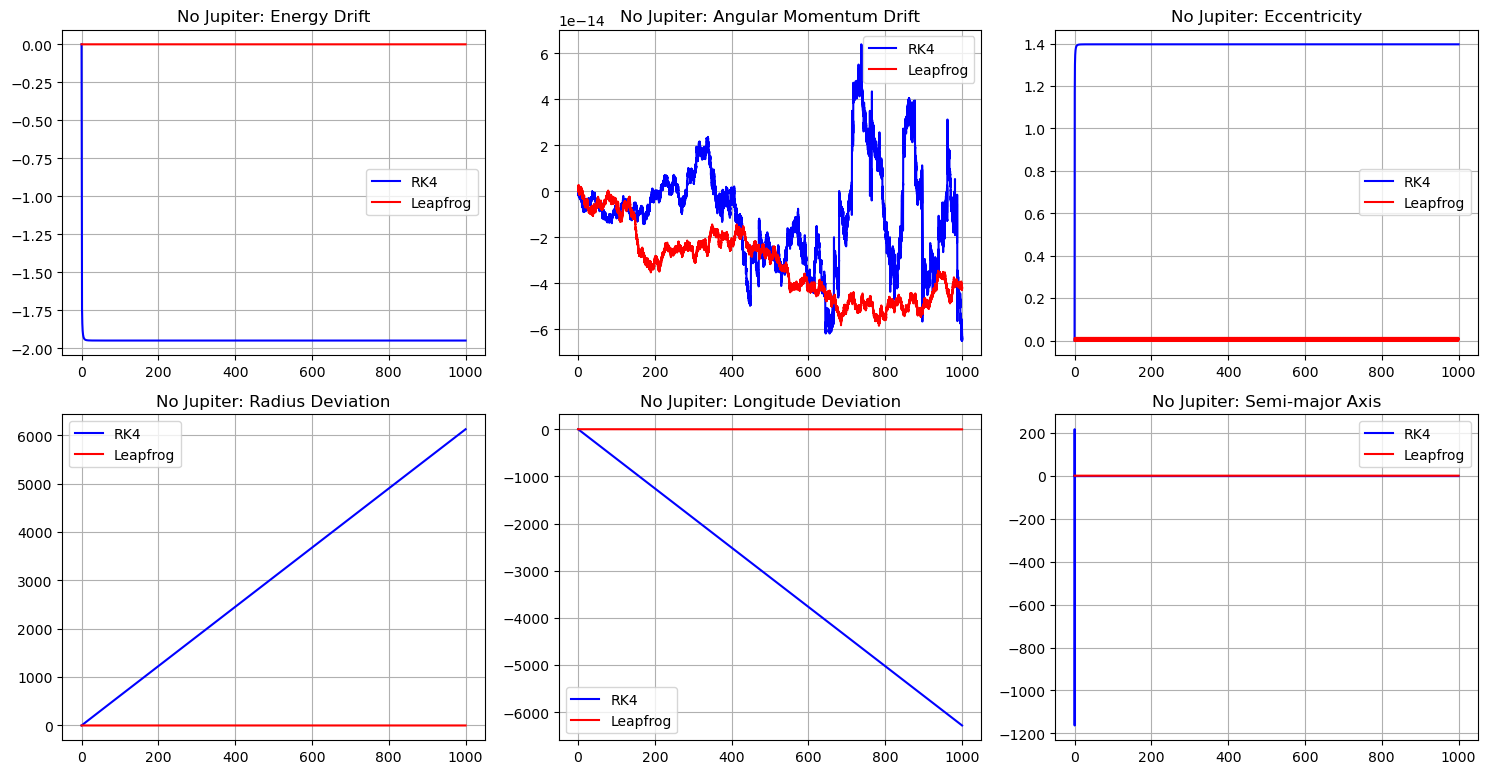

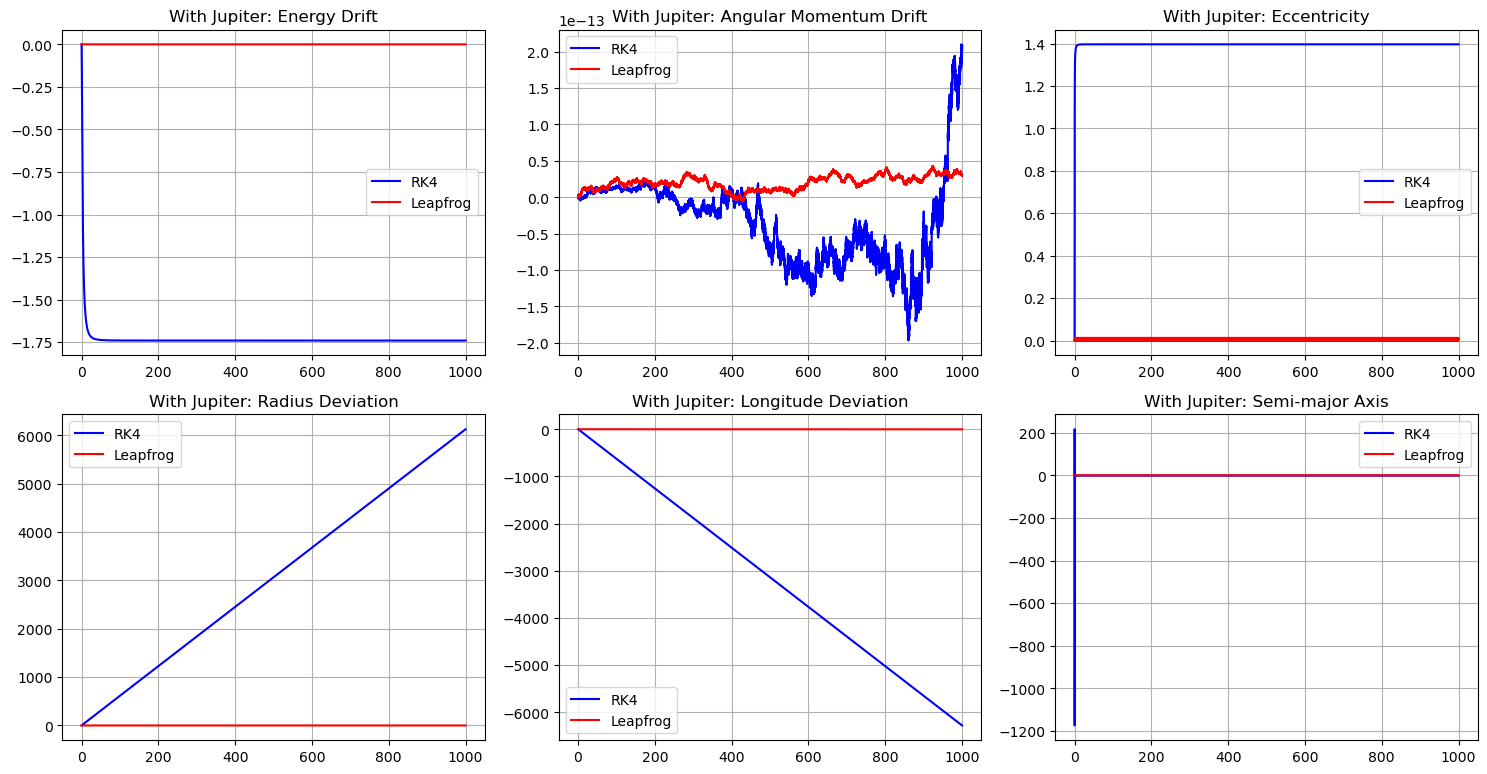

In [54]:
dt = 0.002        # 0.002 yr ≈ 0.73 days
steps = int(1000 / dt)   # 1000 years

def run_all_plots():
# WITHOUT Jupiter
    r_rk4_noJ, lon_rk4_noJ, E_rk4_noJ, L_rk4_noJ, ecc_rk4_noJ, a_rk4_noJ = \
        run_and_extract(rk4_step, dt, steps, 'sun_earth')
    r_lf_noJ, lon_lf_noJ, E_lf_noJ, L_lf_noJ, ecc_lf_noJ, a_lf_noJ = \
        run_and_extract(leapfrog_step, dt, steps, 'sun_earth')

    # WITH Jupiter
    r_rk4_J, lon_rk4_J, E_rk4_J, L_rk4_J, ecc_rk4_J, a_rk4_J = \
        run_and_extract(rk4_step, dt, steps, 'sun_earth_jupiter')
    r_lf_J, lon_lf_J, E_lf_J, L_lf_J, ecc_lf_J, a_lf_J = \
        run_and_extract(leapfrog_step, dt, steps, 'sun_earth_jupiter')

    time = np.arange(steps) * dt

    plot_compare(time, r_rk4_noJ, r_lf_noJ, lon_rk4_noJ, lon_lf_noJ,
                 E_rk4_noJ, E_lf_noJ, L_rk4_noJ, L_lf_noJ,
                 ecc_rk4_noJ, ecc_lf_noJ, a_rk4_noJ, a_lf_noJ,
                 "No Jupiter")

    plot_compare(time, r_rk4_J, r_lf_J, lon_rk4_J, lon_lf_J,
                 E_rk4_J, E_lf_J, L_rk4_J, L_lf_J,
                 ecc_rk4_J, ecc_lf_J, a_rk4_J, a_lf_J,
                 "With Jupiter")
run_all_plots()

In [55]:
# 7. Daily insolation and Laskar reference data
def daily_insolation(S0, r_AU, phi_rad, delta_rad):
    """
    Daily-mean insolation at latitude phi_rad, given distance r_AU and
    solar declination delta_rad.
    """
    cos_phi = np.cos(phi_rad)
    sin_phi = np.sin(phi_rad)
    sin_delta = np.sin(delta_rad)
    cos_delta = np.cos(delta_rad)

    h0 = np.arccos(np.clip(-np.tan(phi_rad) * np.tan(delta_rad), -1, 1))
    Q = (S0 / np.pi) * (1.0 / r_AU**2) * (
        h0 * sin_phi * sin_delta + cos_phi * cos_delta * np.sin(h0)
    )
    return Q

In [56]:
# Load Laskar 2004 orbital data
ref_data = np.loadtxt("orbital_data.txt")
t_kyr_ref = ref_data[:, 0]      # kyr
ecc_ref = ref_data[:, 1]
prec_ref = ref_data[:, 2]       # e sin(ω)
obl_ref = ref_data[:, -1]       # obliquity (radians)

varpi_ref = np.arcsin(np.clip(prec_ref / ecc_ref, -1, 1))

# Radius and insolation at summer solstice
r_solstice_ref = (1 - ecc_ref**2) / (1 + ecc_ref * np.cos(np.pi/2 - varpi_ref))
delta_solstice_ref = np.arcsin(np.sin(obl_ref) * np.sin(np.pi/2))
Q_summer_ref = daily_insolation(S0, r_solstice_ref, phi_65N, delta_solstice_ref)

In [57]:
# 8. Simulation data (100 kyr) and insolation
sim_file = "combined100k_data.txt"
if not os.path.exists(sim_file):
    raise FileNotFoundError("Please provide combined100k_data.txt")

sim_data = np.loadtxt(sim_file)
time_years_sim = sim_data[:, 0]
ecc_sim = sim_data[:, 1]
prec_sim = sim_data[:, 2]
obl_sim = sim_data[:, 3]
r_sim = sim_data[:, 4]
lon_sim = sim_data[:, -1]

t_kyr_sim = time_years_sim / 1000.0
varpi_sim = np.arcsin(np.clip(prec_sim / ecc_sim, -1, 1))

r_solstice_sim = (1 - ecc_sim**2) / (1 + ecc_sim * np.cos(np.pi/2 - varpi_sim))
delta_solstice_sim = np.arcsin(np.sin(obl_sim) * np.sin(np.pi/2))
Q_summer_sim = daily_insolation(S0, r_solstice_sim, phi_65N, delta_solstice_sim)

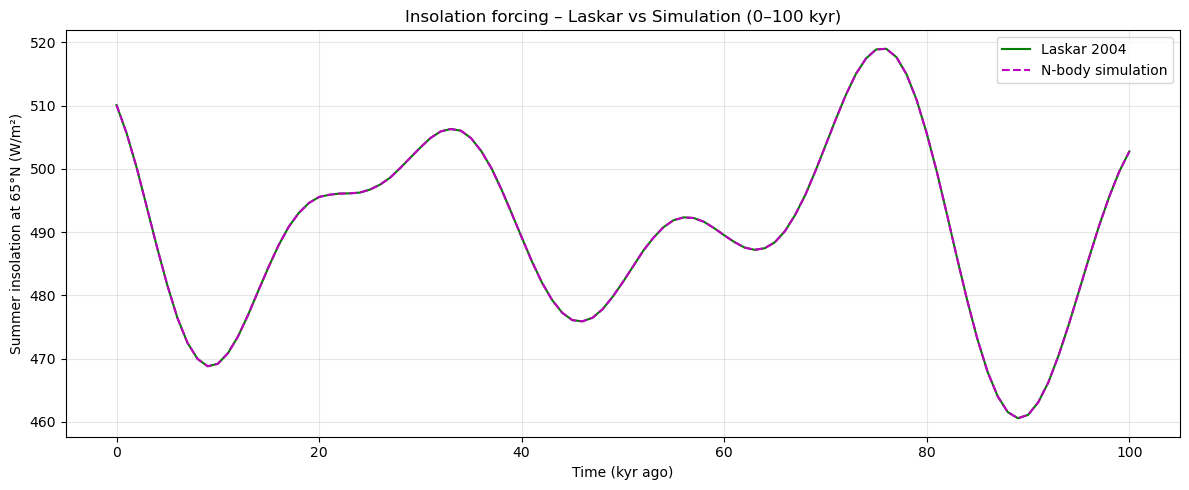

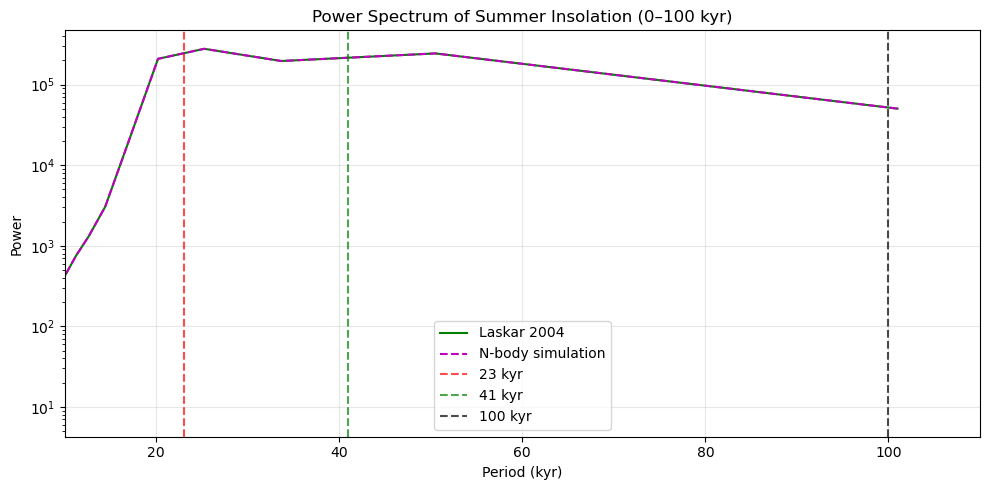

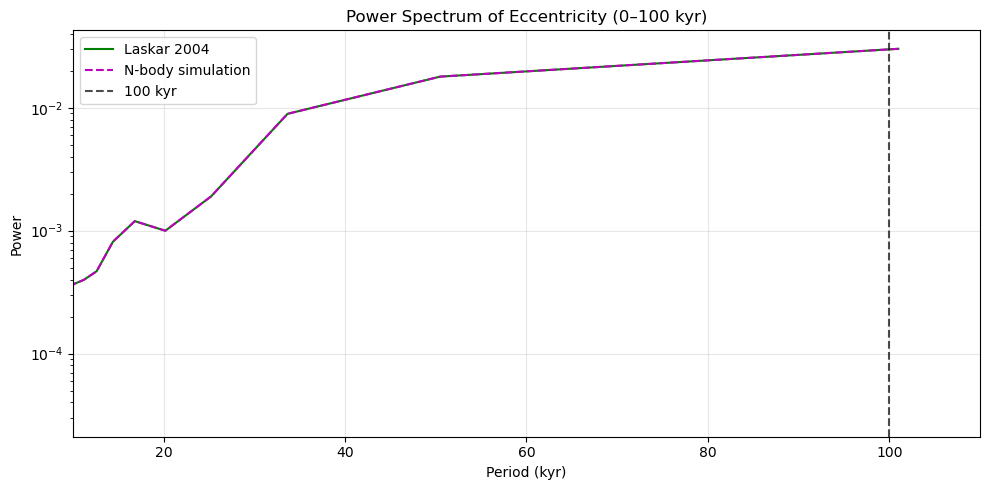

Dominant periods from Laskar insolation (kyr): [50.5  25.25]
Dominant periods from simulation insolation (kyr): [50.5  25.25]


In [68]:
# 9. Laskar vs simulation: time series and spectra (0–100 kyr)
# Regular 1-kyr grid for 0–100 kyr
t_kyr_reg = np.arange(0, 101, 1)

# Interpolate simulation insolation and eccentricity to 1-kyr grid
interp_Q = interp1d(t_kyr_sim, Q_summer_sim, kind='linear',
                    bounds_error=False, fill_value='extrapolate')
Q_sim_reg = interp_Q(t_kyr_reg)

interp_ecc = interp1d(t_kyr_sim, ecc_sim, kind='linear',
                      bounds_error=False, fill_value='extrapolate')
ecc_sim_reg = interp_ecc(t_kyr_reg)

# Reference data already at 1-kyr spacing; mask to 0–100 kyr
mask_ref_100 = t_kyr_ref <= 100
t_ref_reg = t_kyr_ref[mask_ref_100]
Q_ref_reg = Q_summer_ref[mask_ref_100]
ecc_ref_reg = ecc_ref[mask_ref_100]

# Plot: insolation time series
plt.figure(figsize=(12, 5))
plt.plot(t_ref_reg, Q_ref_reg, 'g-', linewidth=1.5, label='Laskar 2004')
plt.plot(t_kyr_reg, Q_sim_reg, 'm--', linewidth=1.5, label='N-body simulation')
plt.xlabel('Time (kyr ago)')
plt.ylabel('Summer insolation at 65°N (W/m²)')
plt.title('Insolation forcing – Laskar vs Simulation (0–100 kyr)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Power spectra
n_points = len(t_kyr_reg)
dt_yr = 1000.0
freq = rfftfreq(n_points, d=dt_yr)
period_kyr = np.zeros_like(freq)
nonzero = freq != 0.0
period_kyr[nonzero] = 1.0 / (freq[nonzero] * 1000.0)

power_ref_reg = np.abs(rfft(Q_ref_clean)) ** 2
power_sim_reg = np.abs(rfft(Q_sim_clean)) ** 2
freq = freq[1:]
period_kyr = period_kyr[1:]
power_ref_reg = power_ref_reg[1:]
power_sim_reg = power_sim_reg[1:]

plt.figure(figsize=(10, 5))
plt.semilogy(period_kyr, power_ref_reg, 'g-', linewidth=1.5, label='Laskar 2004')
plt.semilogy(period_kyr, power_sim_reg, 'm--', linewidth=1.5, label='N-body simulation')
plt.xlim(10, 110)
plt.xlabel('Period (kyr)')
plt.ylabel('Power')
plt.title('Power Spectrum of Summer Insolation (0–100 kyr)')
plt.axvline(23, color='r', linestyle='--', alpha=0.7, label='23 kyr')
plt.axvline(41, color='g', linestyle='--', alpha=0.7, label='41 kyr')
plt.axvline(100, color='k', linestyle='--', alpha=0.7, label='100 kyr')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Power spectra of eccentricity on same grid
power_ecc_ref = np.abs(rfft(detrend(ecc_ref_reg)))**2
power_ecc_sim = np.abs(rfft(detrend(ecc_sim_reg)))**2
power_ecc_ref = power_ecc_ref[1:]
power_ecc_sim = power_ecc_sim[1:]

plt.figure(figsize=(10, 5))
plt.semilogy(period_kyr, power_ecc_ref, 'g-', linewidth=1.5, label='Laskar 2004')
plt.semilogy(period_kyr, power_ecc_sim, 'm--', linewidth=1.5, label='N-body simulation')
plt.xlim(10, 110)
plt.xlabel('Period (kyr)')
plt.ylabel('Power')
plt.title('Power Spectrum of Eccentricity (0–100 kyr)')
plt.axvline(100, color='k', linestyle='--', alpha=0.7, label='100 kyr')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Dominant periods from insolation spectra
peaks_ref, _ = find_peaks(power_ref_reg, height=np.max(power_ref_reg) * 0.1)
peaks_sim, _ = find_peaks(power_sim_reg, height=np.max(power_sim_reg) * 0.1)

print("Dominant periods from Laskar insolation (kyr):",
      period_kyr[peaks_ref][:3])
print("Dominant periods from simulation insolation (kyr):",
      period_kyr[peaks_sim][:3])

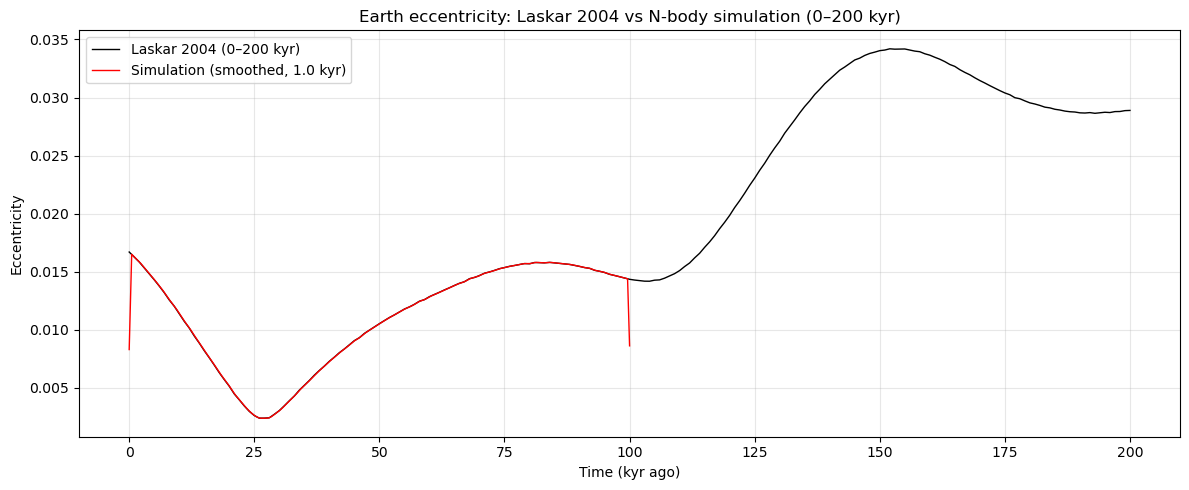

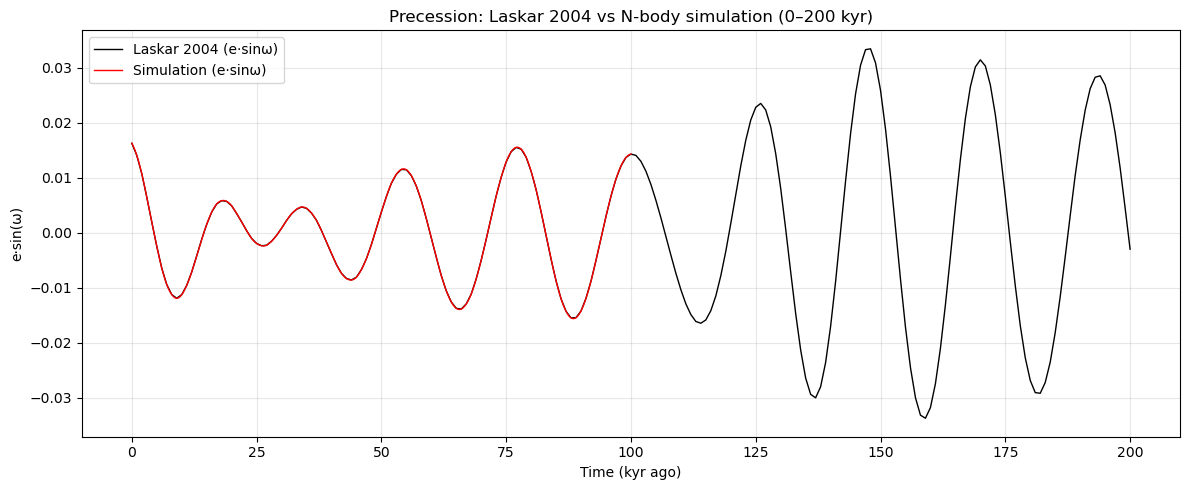

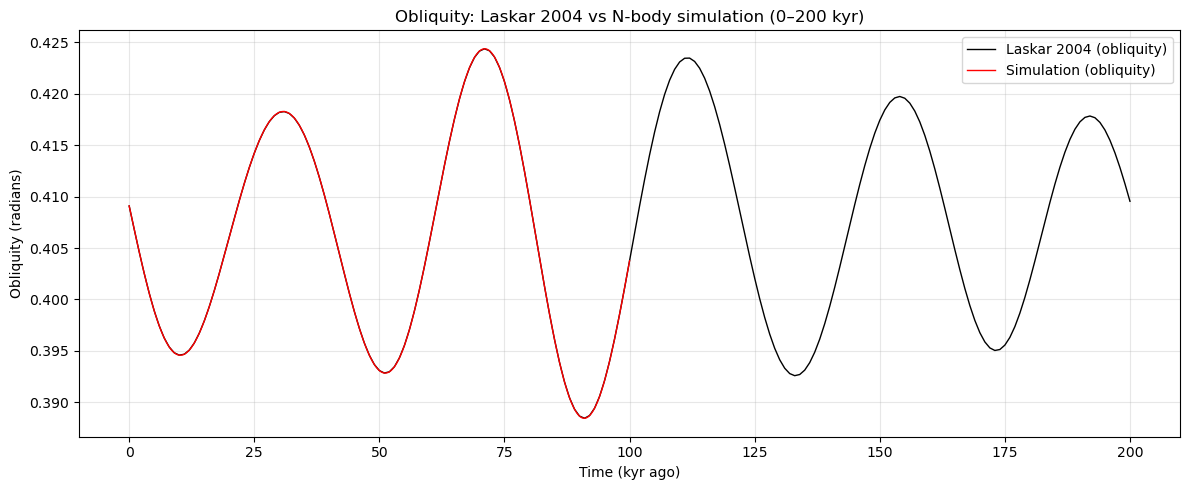

In [59]:
# 10. Comparison of orbital elements (0–200 kyr)
# Smooth simulation eccentricity for comparison
window_kyr = 1.0
dt_sim_yr = time_years_sim[1] - time_years_sim[0]
window_size = int(window_kyr * 1000.0 / dt_sim_yr)
window_size = max(1, window_size)
ecc_sim_smoothed = np.convolve(
    ecc_sim, np.ones(window_size) / window_size, mode='same'
)

mask_ref_200 = t_kyr_ref <= 200
t_laskar_masked = t_kyr_ref[mask_ref_200]
ecc_laskar_masked = ecc_ref[mask_ref_200]
prec_laskar_masked = prec_ref[mask_ref_200]
obl_laskar_masked = obl_ref[mask_ref_200]

# Eccentricity
plt.figure(figsize=(12, 5))
plt.plot(t_laskar_masked, ecc_laskar_masked, 'k-', linewidth=1,
         label='Laskar 2004 (0–200 kyr)')
plt.plot(t_kyr_sim, ecc_sim_smoothed, 'r-', linewidth=1,
         label=f'Simulation (smoothed, {window_kyr} kyr)')
plt.xlabel('Time (kyr ago)')
plt.ylabel('Eccentricity')
plt.title('Earth eccentricity: Laskar 2004 vs N-body simulation (0–200 kyr)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Precession (e sin ω)
plt.figure(figsize=(12, 5))
plt.plot(t_laskar_masked, prec_laskar_masked, 'k-', linewidth=1,
         label='Laskar 2004 (e·sinω)')
plt.plot(t_kyr_sim, prec_sim, 'r-', linewidth=1,
         label='Simulation (e·sinω)')
plt.xlabel('Time (kyr ago)')
plt.ylabel('e·sin(ω)')
plt.title('Precession: Laskar 2004 vs N-body simulation (0–200 kyr)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Obliquity
plt.figure(figsize=(12, 5))
plt.plot(t_laskar_masked, obl_laskar_masked, 'k-', linewidth=1,
         label='Laskar 2004 (obliquity)')
plt.plot(t_kyr_sim, obl_sim, 'r-', linewidth=1,
         label='Simulation (obliquity)')
plt.xlabel('Time (kyr ago)')
plt.ylabel('Obliquity (radians)')
plt.title('Obliquity: Laskar 2004 vs N-body simulation (0–200 kyr)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

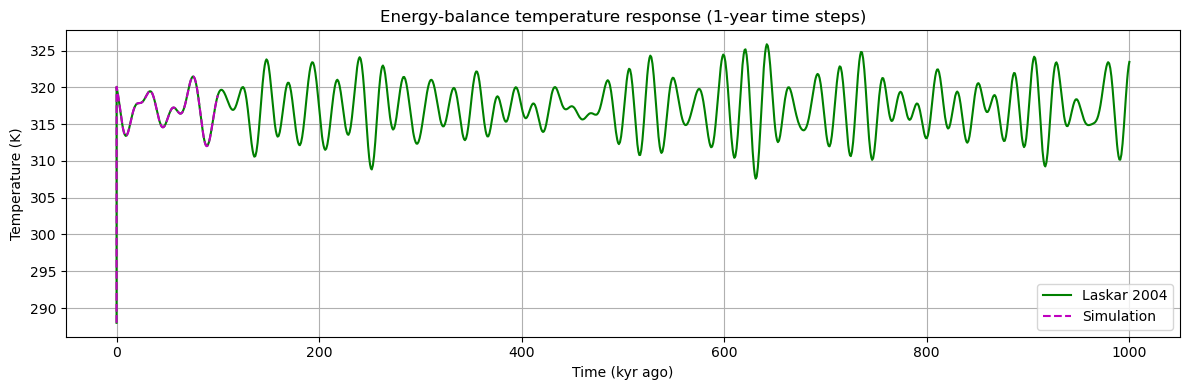

In [60]:
# 11. Simple energy-balance model
sigma = 5.67e-8   # W/m^2/K^4
albedo = 0.3
epsilon = 0.6
C_heat = 4e8      # J/m^2/K

def run_energy_balance(Q_summer, time_years, dt_years=1.0):
    """
    Simple zero-dimensional energy-balance model driven by summer insolation.
    Q_summer: W/m^2
    time_years: array of years
    dt_years: time step for integration (years)
    """
    t_fine = np.arange(time_years[0], time_years[-1], dt_years)
    Q_fine = interp1d(time_years, Q_summer, kind='linear',
                      fill_value='extrapolate')(t_fine)

    T = np.zeros_like(Q_fine)
    T[0] = 288.0  # initial temperature (K)
    dt_seconds = dt_years * 365.25 * 24 * 3600

    for i in range(len(T) - 1):
        E_in = (1 - albedo) * Q_fine[i]
        E_out = epsilon * sigma * T[i]**4
        dT = (E_in - E_out) / C_heat
        T[i + 1] = T[i] + dT * dt_seconds

    return t_fine, T

t_ref_fine, T_ref = run_energy_balance(Q_summer_ref, t_kyr_ref * 1000.0,
                                       dt_years=1.0)
t_sim_fine, T_sim = run_energy_balance(Q_summer_sim, time_years_sim,
                                       dt_years=1.0)

plt.figure(figsize=(12, 4))
plt.plot(t_ref_fine / 1000.0, T_ref, 'g-', label='Laskar 2004')
plt.plot(t_sim_fine / 1000.0, T_sim, 'm--', label='Simulation')
plt.xlabel('Time (kyr ago)')
plt.ylabel('Temperature (K)')
plt.title('Energy-balance temperature response (1-year time steps)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

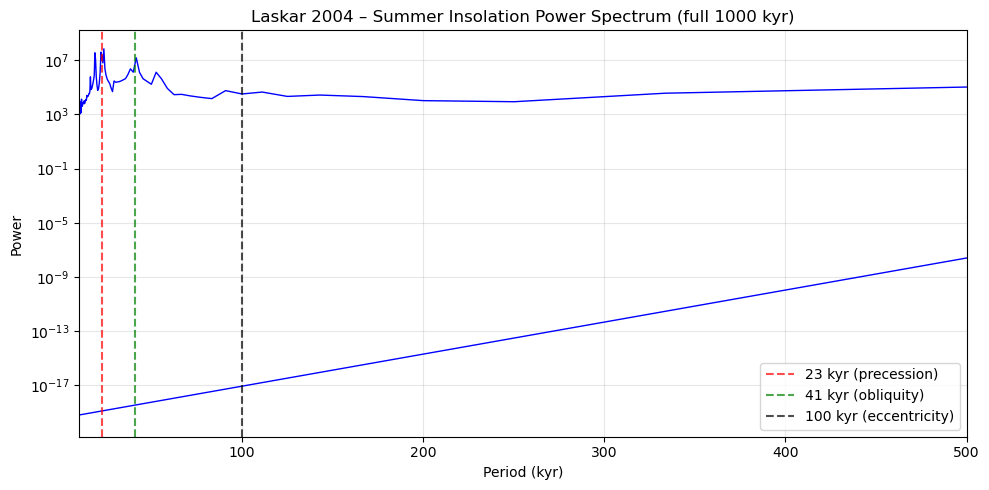

Dominant periods from full 1000 kyr Laskar data (kyr): [23.83333333 22.24444444 18.88679245 41.70833333]


In [61]:
# 12. Full 1000 kyr Laskar spectrum (reference only)
varpi_full = np.arcsin(np.clip(prec_ref / ecc_ref, -1, 1))
r_solstice_full = (1 - ecc_ref**2) / (1 + ecc_ref * np.cos(np.pi/2 - varpi_full))
delta_solstice_full = np.arcsin(np.sin(obl_ref) * np.sin(np.pi/2))
Q_summer_full = daily_insolation(S0, r_solstice_full, phi_65N, delta_solstice_full)

Q_detrend_full = detrend(Q_summer_full)
n_full = len(Q_detrend_full)
dt_yr_full = 1000.0
freq_full = rfftfreq(n_full, d=dt_yr_full)
power_full = np.abs(rfft(Q_detrend_full))**2

period_kyr_full = np.zeros_like(freq_full)
nonzero_full = freq_full != 0.0
period_kyr_full[nonzero_full] = 1.0 / (freq_full[nonzero_full] * 1000.0)

plt.figure(figsize=(10, 5))
plt.semilogy(period_kyr_full, power_full, 'b-', linewidth=1)
plt.xlim(10, 500)
plt.xlabel('Period (kyr)')
plt.ylabel('Power')
plt.title('Laskar 2004 – Summer Insolation Power Spectrum (full 1000 kyr)')
plt.axvline(23, color='r', linestyle='--', alpha=0.7, label='23 kyr (precession)')
plt.axvline(41, color='g', linestyle='--', alpha=0.7, label='41 kyr (obliquity)')
plt.axvline(100, color='k', linestyle='--', alpha=0.7, label='100 kyr (eccentricity)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

peaks_full, _ = find_peaks(power_full, height=np.max(power_full) * 0.1)
dom_periods_full = period_kyr_full[peaks_full]
dom_power_full = power_full[peaks_full]
sorted_idx_full = np.argsort(dom_power_full)[::-1]
print("Dominant periods from full 1000 kyr Laskar data (kyr):",
      dom_periods_full[sorted_idx_full][:5])